# **Which Pokémon in the Pokémon dataset have HP values that are outliers?**

### I will be conducting a census study because I have access to the entire population of Pokemon. I will not be manipulating variables.

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("pokemon.csv")

In [29]:
Q1 = df["hp"].quantile(0.25)
Q3 = df["hp"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (
    df[(df["hp"] < lower) | (df["hp"] > upper)]
    [["english_name", "hp"]]
    .sort_values("hp", ascending=False)
    .reset_index(drop=True)
)

<Axes: xlabel='hp'>

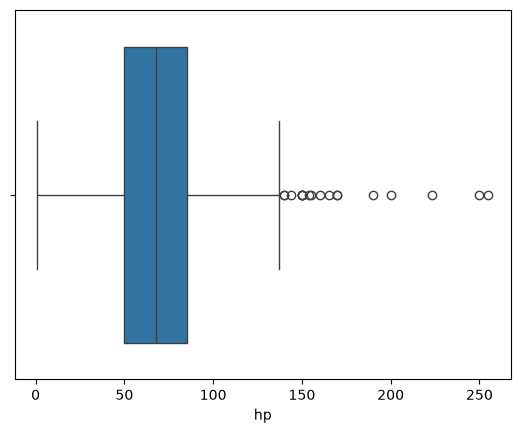

In [31]:
sns.boxplot(x=df["hp"])

### **The boxplot encapsulates the distribution of HP values and highlights outliers that fall above 1.5 x IQR above the third quartile.**

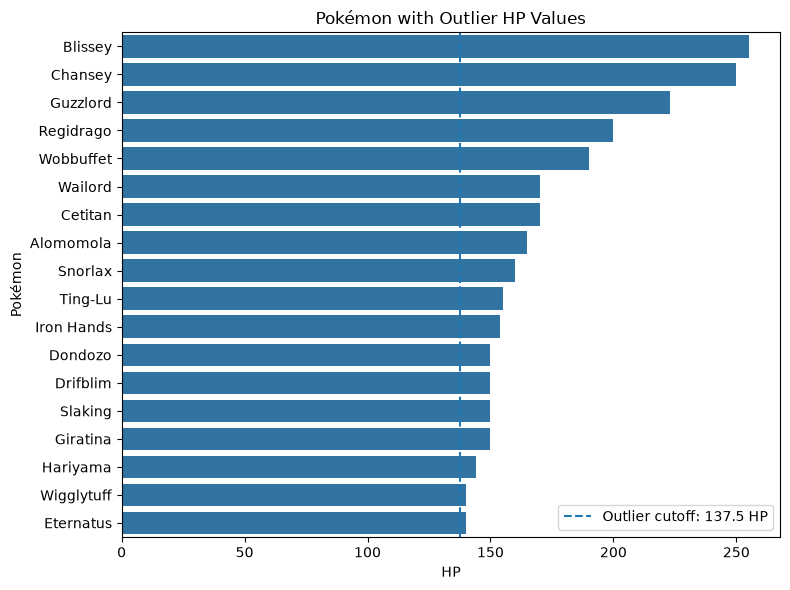

In [30]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=outliers,
    x="hp",
    y="english_name",
    order=outliers["english_name"]
)

plt.axvline(
    upper,
    linestyle="--",
    label=f"Outlier cutoff: {upper:.1f} HP"
)

plt.title("Pokémon with Outlier HP Values")
plt.xlabel("HP")
plt.ylabel("Pokémon")
plt.legend()
plt.tight_layout()
plt.show()

### **The barchart represents Pokémon whose HP values fall above the upper outlier threshold of 137.5 HP.**

## The Pokemon who have outlier HP values are **Blissey, Chansey, Guzzlord, Regidrago, Wobbuffet, Wailord, Cetitan, Alomomola, Snorlax, Ting-Lu, Iron Hands, Dondozo, Drifblim, Slaking, Giratina, Hariyama, Wigglytuff, and Eternatus.** Their HP values fell 1.5 x IQR above Q3, or 1.5 x 35 above Q3 which would give us an outlier threshold of 137.5. There were no lower outliers.